In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [ ]:
train_data = "./affectnet_dataset/train"
test_data = "./affectnet_dataset/test"
len(train_data), len(test_data)

(25, 24)

In [3]:
classes = sorted([d for d in os.listdir(train_data) if d != '.DS_Store'])
print("Classes: ", classes)

Classes:  ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
train_counts = {}
for cls in classes:
    cls_folder = os.path.join(train_data, cls)
    img = [im for im in os.listdir(cls_folder)]
    train_counts[cls] = len(img)
print(train_counts)
print("Total images in training set: ", sum(train_counts.values()))

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}
Total images in training set:  16108


In [19]:
test_counts = {}
for cls in classes:
    cls_folder = os.path.join(test_data, cls)
    img = [im for im in os.listdir(cls_folder)]
    test_counts[cls] = len(img)
print(test_counts)
print("Total images in test set: ", sum(test_counts.values()))


{'anger': 1718, 'contempt': 1312, 'disgust': 1248, 'fear': 1664, 'happy': 2704, 'neutral': 2368, 'sad': 1584, 'surprise': 1920}
Total images in test set:  14518


(-0.5, 95.5, 95.5, -0.5)

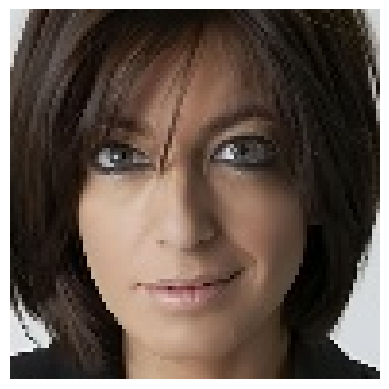

In [15]:
sample_img = cv2.imread(
    os.path.join(
        train_data,
        classes[1],
        os.listdir(os.path.join(train_data, classes[1]))[0]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.axis("off")

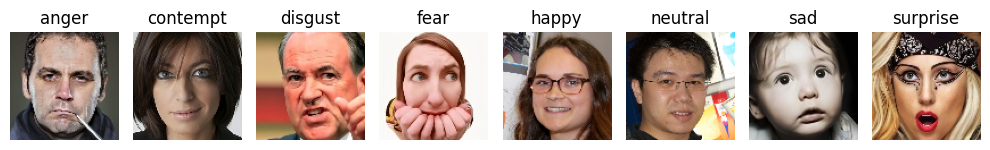

In [8]:
plt.figure(figsize=(10,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_data, cls)
    first_img = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, first_img)

    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()




In [9]:
sizes = []
for cls in os.listdir(train_data):
    cls_path = os.path.join(train_data, cls)

    if not os.path.isdir(cls_path):
        continue
    for im in os.listdir(cls_path):
        img_path = os.path.join(cls_path, im)

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        sizes.append((w,h))

print("Img size: ", set(sizes))


Img size:  {(96, 96)}
